# Cosmopedia-100K 합성 데이터 탐색

Cosmopedia는 Mistral-8x7B-Instruct-v0.1로 생성된 대규모 합성 교육 데이터셋입니다.  

1. 프롬프트와 생성된 합성 텍스트 구조 탐색
2. 합성 데이터 품질 평가 방법 (사실적 오류 / 추론 오류)
3. 프롬프트 변형으로 더 다양한 데이터 생성

## 1. 환경 설정

In [1]:
!pip install datasets pandas matplotlib seaborn anthropic -q

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import random
import re
import textwrap
from collections import Counter
from datasets import load_dataset

# 한글 폰트 설정 (macOS)
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

random.seed(42)

## 2. Cosmopedia-100K 데이터셋 로드

In [3]:
ds = load_dataset("HuggingFaceTB/cosmopedia-100k", split="train")
print(f"총 샘플 수: {len(ds):,}")
print(f"컬럼: {ds.column_names}")

README.md:   0%|          | 0.00/944 [00:00<?, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/153M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/153M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/100000 [00:00<?, ? examples/s]

총 샘플 수: 100,000
컬럼: ['prompt', 'text_token_length', 'text', 'seed_data', 'format', 'audience']


In [4]:
df = ds.to_pandas()
df.head(3)

,prompt,text_token_length,text,seed_data,format,audience
0,"Here is an extract from a webpage: ""What can c...",585,When you've been involved in an auto accident...,web_samples_v2,blogpost,general
1,"Here is an extract from a webpage: ""The LISA P...",896,Course Unit: LISA Pathfinder Mission and Grav...,web_samples_v1,textbook_academic_tone,college_students
2,"Here is an extract from a webpage: ""Recording ...",701,Title: Making Mathematics Accessible: The Imp...,web_samples_v1,blogpost,general


## 3. 데이터 구조 탐색

### 3-1. 소스(seed) 분포
Cosmopedia는 여러 seed 소스(웹 크롤링, 교과서 등)에서 프롬프트를 생성합니다.

format
blogpost                   37927
textbook_academic_tone     28261
educational_piece           6203
story_reddit                4235
story_children              4160
story_life_lessons          4056
wikihow                     3979
textbook_narrative_tone     3606
textbook_narrative          3364
story_morality              1915
story_forums                1879
e-learning_module            208
textbook_academic            108
scientific_article            99
Name: count, dtype: int64


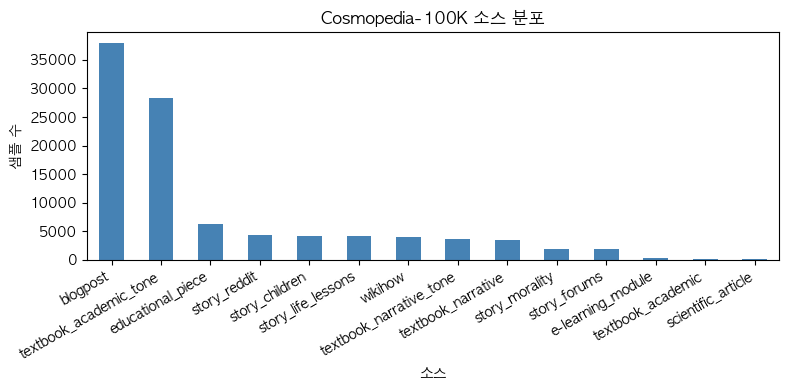

In [5]:
source_counts = df["format"].value_counts() if "format" in df.columns else df["seed_data"].value_counts()
print(source_counts)

fig, ax = plt.subplots(figsize=(8, 4))
source_counts.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Cosmopedia-100K 소스 분포")
ax.set_xlabel("소스")
ax.set_ylabel("샘플 수")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### 3-2. 프롬프트 & 합성 텍스트 샘플 확인

In [6]:
def show_sample(idx: int):
    row = df.iloc[idx]
    print("=" * 70)
    print(f"[INDEX] {idx}")
    print(f"[SEED SOURCE] {row.get('seed_data', row.get('format', 'N/A'))}")
    print("-" * 70)
    print("[PROMPT]")
    print(textwrap.fill(row["prompt"], width=80))
    print("-" * 70)
    print("[SYNTHETIC TEXT (앞 500자)]")
    print(row["text"][:500])
    print("=" * 70)

# 무작위 3개 샘플 출력
for idx in random.sample(range(len(df)), 3):
    show_sample(idx)

[INDEX] 83810
[SEED SOURCE] web_samples_v1
----------------------------------------------------------------------
[PROMPT]
Here is an extract from a webpage: "160 likes | 367 Vues Video Game Addiction.
By; Meghan Kraakman. E N D Video Game Addiction By; Meghan Kraakman Video game
addiction, also known as video game overuse, is extreme use of computer and
video games that interferes with daily life. Instances have been reported in
which users play compulsively, isolating themselves from family and friends or
from other forms of social contact, and focus almost entirely on in-game
achievements rather than other life events, also lack of imagination and will be
very moody. ;Example of video gaming getting out of control; The press has
reported concerns over online gaming since at least 1994, when wired magazine
mentioned a college student who was playing a “mud” for 12 hours a day instead
of attending class. there is increasing evidence that people of all ages,
especially teens and pre-te

### 3-3. 텍스트 길이 분포

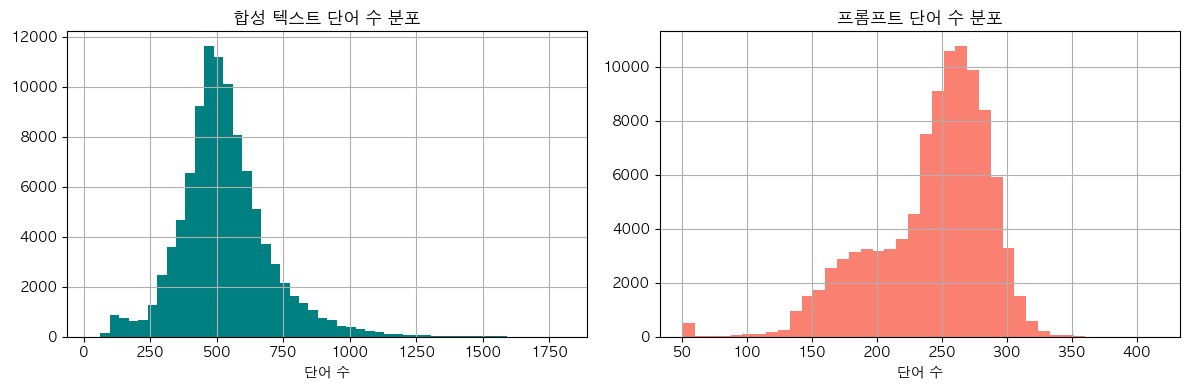

       prompt_len  text_len
count    100000.0  100000.0
mean        242.3     530.4
std          44.7     170.2
min          51.0      27.0
25%         218.0     432.0
50%         253.0     513.0
75%         274.0     611.0
max         415.0    1805.0


In [7]:
df["text_len"] = df["text"].str.split().str.len()
df["prompt_len"] = df["prompt"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["text_len"].clip(upper=2000).hist(bins=50, ax=axes[0], color="teal")
axes[0].set_title("합성 텍스트 단어 수 분포")
axes[0].set_xlabel("단어 수")

df["prompt_len"].hist(bins=40, ax=axes[1], color="salmon")
axes[1].set_title("프롬프트 단어 수 분포")
axes[1].set_xlabel("단어 수")
plt.tight_layout()
plt.show()

print(df[["prompt_len", "text_len"]].describe().round(1))

## 4. 합성 데이터 품질 평가

합성 데이터의 품질 문제는 크게 세 가지 범주로 나뉩니다:
- **헤지 표현 과잉**: "I think", "It could be", "I'm not sure" 등 불확실한 표현
- **사실적 오류**: 날짜, 수치, 이름 등 검증 가능한 사실의 오류
- **추론 오류**: 논리적 비약, 인과관계 혼동, 순환 논리

### 4-1. 헤지 표현(Hedging) 탐지 — 신뢰도 저하 신호

In [8]:
HEDGE_PATTERNS = [
    r"\bI think\b", r"\bI believe\b", r"\bI'm not sure\b", r"\bI'm not certain\b",
    r"\bIt could be\b", r"\bIt might be\b", r"\bperhaps\b", r"\bmaybe\b",
    r"\bprobably\b", r"\bI guess\b", r"\bI suppose\b", r"\bI'm afraid\b",
    r"\bAs an AI\b", r"\bAs a language model\b",
]

def count_hedges(text: str) -> int:
    return sum(len(re.findall(p, text, re.IGNORECASE)) for p in HEDGE_PATTERNS)

def find_hedge_sentences(text: str) -> list[str]:
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s for s in sentences if count_hedges(s) > 0]

df["hedge_count"] = df["text"].apply(count_hedges)

print(f"헤지 표현이 1개 이상인 샘플: {(df['hedge_count'] > 0).sum():,} / {len(df):,}")
print(f"\n헤지 표현 상위 5개 샘플:")
top_hedge = df.nlargest(5, "hedge_count")[["prompt", "hedge_count", "text"]]
for _, row in top_hedge.iterrows():
    print(f"\n  hedge_count={row['hedge_count']}")
    print(f"  prompt: {row['prompt'][:80]}...")
    hedge_sents = find_hedge_sentences(row["text"])
    for s in hedge_sents[:2]:
        print(f"    → {s[:120]}")

헤지 표현이 1개 이상인 샘플: 10,902 / 100,000

헤지 표현 상위 5개 샘플:

  hedge_count=8
  prompt: Write a compelling story related to the following text snippet:
“Can you recomme...
    → I've been doing some research, and I think I might have found something that could help me find what I'm looking for."


    → Maybe then I can finally figure out who I am and where I'm going."

Sarah hesitated before speaking again.

  hedge_count=7
  prompt: Here is an extract from a webpage: "From the #1 New York Times bestselling autho...
    →  Title: Personal Growth and Empowerment in Maybe Someday

Have you ever found yourself in a situation where your world s
    → If so, then you might relate to Sydney, the protagonist in Colleen Hoover’s novel “Maybe Someday.” This gripping story o

  hedge_count=6
  prompt: Write a compelling story related to the following text snippet:
“Were there any ...
    → "Edward," he said, his tone serious yet warm, "I believe our people could learn much from each other through these 

### 4-2. 사실적 오류 관찰 — 숫자/날짜 일관성 검사

In [9]:
"""
사실 오류 자동 검출의 한계:
  - LLM 합성 데이터는 외부 DB 없이 완전한 팩트체크가 어렵습니다.
  - 여기서는 두 가지 대리 지표(proxy)로 관찰합니다:
    1) 연도 범위 이상 (미래 연도, 너무 오래된 연도)
    2) 텍스트 내 숫자 밀도 — 숫자가 과도하게 많은 경우 hallucination 위험이 높습니다.
"""

YEAR_PATTERN = re.compile(r"\b(1[0-9]{3}|2[0-9]{3})\b")

def extract_years(text: str) -> list[int]:
    return [int(y) for y in YEAR_PATTERN.findall(text)]

def year_anomaly_score(text: str) -> int:
    years = extract_years(text)
    if not years:
        return 0
    return sum(1 for y in years if y > 2026 or y < 1900)

def numeric_density(text: str) -> float:
    words = text.split()
    if not words:
        return 0.0
    num_count = sum(1 for w in words if re.search(r"\d", w))
    return num_count / len(words)

df["year_anomaly"] = df["text"].apply(year_anomaly_score)
df["numeric_density"] = df["text"].apply(numeric_density)

print("=== 연도 이상치가 있는 샘플 (상위 5) ===")
anom = df[df["year_anomaly"] > 0].nlargest(5, "year_anomaly")
for _, row in anom.iterrows():
    years = extract_years(row["text"])
    future = [y for y in years if y > 2026]
    print(f"  이상 연도={future}, prompt: {row['prompt'][:70]}...")

print("\n=== 숫자 밀도 상위 5 샘플 ===")
dense = df.nlargest(5, "numeric_density")[["prompt", "numeric_density", "text"]]
for _, row in dense.iterrows():
    print(f"  density={row['numeric_density']:.3f}, text 앞부분: {row['text'][:100]}...")

=== 연도 이상치가 있는 샘플 (상위 5) ===
  이상 연도=[], prompt: Write a comprehensive and in-depth textbook on 'U.S. History', tailore...
  이상 연도=[], prompt: Write a long and very detailed course unit for a textbook on "Michelan...
  이상 연도=[], prompt: Write a long and very detailed course unit for a textbook on "Renaissa...
  이상 연도=[], prompt: Write a long and very detailed course unit for a textbook on "The Scie...
  이상 연도=[], prompt: Write a long and very detailed course unit for a textbook on "Jewish M...

=== 숫자 밀도 상위 5 샘플 ===
  density=0.322, text 앞부분:  To solve the system of linear equations using matrices, we can first write the coefficients of the ...
  density=0.292, text 앞부분:  To determine whether the vector (6,9,-9,-9) belongs to the subspace S of R^4 with the given basis, ...
  density=0.291, text 앞부분:  To begin, let's clarify the concept of symbolic computation and its role in mathematics. Symbolic c...
  density=0.273, text 앞부분:  To find the area of the region bounded by the curves $y =

### 4-3. 추론 오류 관찰 — 논리 마커 분석

In [ ]:
"""
추론 오류 대리 지표:
  - 인과 마커(therefore, thus, hence, so, because) 뒤에 헤지 표현이 오는 경우
    → "X이기 때문에 아마도 Y일 수 있다" 형태는 추론의 확신 부족을 나타냄
  - 반복적 순환 문장: 동일한 n-gram이 짧은 간격 안에 여러 번 등장
"""

CAUSAL_MARKERS = re.compile(
    r"\b(therefore|thus|hence|so|because|consequently|as a result)\b",
    re.IGNORECASE
)
HEDGE_RE = re.compile(
    r"\b(maybe|perhaps|probably|might|could be|I think|I believe)\b",
    re.IGNORECASE
)

def causal_hedge_score(text: str) -> int:
    """인과 마커 뒤 같은 문장에 헤지 표현이 오는 횟수"""
    sentences = re.split(r"(?<=[.!?])\s+", text)
    score = 0
    for s in sentences:
        if CAUSAL_MARKERS.search(s) and HEDGE_RE.search(s):
            score += 1
    return score

def repetition_score(text: str, ngram: int = 6, threshold: int = 3) -> int:
    """동일한 n-gram이 threshold 이상 반복되는 수"""
    words = text.lower().split()
    grams = [" ".join(words[i:i+ngram]) for i in range(len(words) - ngram + 1)]
    counts = Counter(grams)
    return sum(1 for c in counts.values() if c >= threshold)

df["causal_hedge"] = df["text"].apply(causal_hedge_score)
df["repetition"] = df["text"].apply(repetition_score)

print("=== 인과+헤지 혼용 상위 5 샘플 ===")
for _, row in df.nlargest(5, "causal_hedge").iterrows():
    sents = re.split(r"(?<=[.!?])\s+", row["text"])
    flagged = [s for s in sents if CAUSAL_MARKERS.search(s) and HEDGE_RE.search(s)]
    print(f"\n  causal_hedge={row['causal_hedge']}")
    for s in flagged[:2]:
        print(f"  → {s[:130]}")

print("\n=== 반복 n-gram 상위 5 샘플 ===")
for _, row in df.nlargest(5, "repetition").iterrows():
    print(f"  repetition={row['repetition']}, prompt: {row['prompt'][:80]}...")

### 4-4. 품질 점수 종합 및 시각화

In [ ]:
# 낮을수록 품질이 높음: 각 지표를 0~1로 정규화 후 합산
from sklearn.preprocessing import MinMaxScaler

quality_cols = ["hedge_count", "year_anomaly", "numeric_density", "causal_hedge", "repetition"]
scaler = MinMaxScaler()
df_q = df[quality_cols].copy().fillna(0)
df["quality_risk"] = scaler.fit_transform(df_q).sum(axis=1)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(quality_cols):
    df[col].clip(upper=df[col].quantile(0.99)).hist(bins=40, ax=axes[i], color="steelblue")
    axes[i].set_title(col)
df["quality_risk"].hist(bins=40, ax=axes[5], color="tomato")
axes[5].set_title("quality_risk (종합)")
plt.tight_layout()
plt.show()

print("\n품질 위험 점수 상위 10 샘플의 프롬프트:")
for _, row in df.nlargest(10, "quality_risk").iterrows():
    print(f"  risk={row['quality_risk']:.2f} | {row['prompt'][:80]}...")

## 5. 프롬프트 변형으로 다양한 데이터 생성

Cosmopedia 프롬프트를 분석하면 공통 템플릿 구조가 보입니다.  
세 가지 차원으로 변형합니다:
1. **청중(Audience)**: 초등학생 / 대학생 / 전문가
2. **형식(Format)**: 교과서 / 스토리 / 질문-답변 / 블로그
3. **관점(Perspective)**: 역사적 / 현대적 / 비판적

### 5-1. 원본 프롬프트 템플릿 추출 및 분석

In [10]:
# Cosmopedia 프롬프트의 공통 패턴 파악
sample_prompts = df["prompt"].sample(20, random_state=42).tolist()
for i, p in enumerate(sample_prompts[:5]):
    print(f"[{i}] {p[:200]}")
    print()

[0] Here is an extract from a webpage: "If you ever need help or are scared or in a dark place, please please please reach out. You can comment here (and I can reply via email based on the address you ent

[1] Write a long and very detailed course unit for a textbook on "Introduction to African Studies I: Africa in the 20th Century " intended for college students.
We have already covered chapter(s) "1. Intr

[2] Here is an extract from a webpage: "As soon as I learned about Trabzonspor’s team composition, I was worried. In my general views about Trabzon, the subject that I focused on the most was the formatio

[3] Here is an extract from a webpage: "Catherine Canino | Flower Pearl Hoops
Regular price$122.00
/
Shipping calculated at checkout.
Exotic, rare freshwater flowers -
- Baroque, organic pearls in flower 

[4] Here is an extract from a webpage: "Trash and Recycling
This page provides the information you need to get rid of your trash and recyclables, while helping to limit the imp

### 5-2. 프롬프트 변형 템플릿 정의

In [ ]:
AUDIENCE_TEMPLATES = {
    "elementary": (
        "Write a short, simple educational text for elementary school children (ages 8-10) "
        "about {topic}. Use easy words, fun analogies, and avoid technical jargon. "
        "Keep it under 200 words."
    ),
    "undergraduate": (
        "Write a clear, informative educational passage for undergraduate students "
        "about {topic}. Include key concepts, relevant examples, and encourage "
        "critical thinking. Around 300 words."
    ),
    "expert": (
        "Write a rigorous, technically detailed passage for domain experts "
        "about {topic}. Use precise terminology, reference current understanding, "
        "and highlight open questions in the field. Around 400 words."
    ),
}

FORMAT_TEMPLATES = {
    "textbook": (
        "Write a textbook-style section about {topic}. "
        "Include a definition, key properties, real-world applications, and a summary."
    ),
    "story": (
        "Tell an engaging story or narrative that naturally explains {topic}. "
        "Use characters and plot to make abstract concepts concrete."
    ),
    "qa": (
        "Create a question-and-answer format educational piece about {topic}. "
        "Include 5 questions with detailed answers that build understanding progressively."
    ),
    "blog": (
        "Write an informal, engaging blog post about {topic}. "
        "Use a conversational tone, include surprising facts, and end with a call to action."
    ),
}

PERSPECTIVE_TEMPLATES = {
    "historical": (
        "Write about {topic} from a historical perspective. "
        "Trace how our understanding has evolved from early discoveries to the present."
    ),
    "contemporary": (
        "Write about {topic} focusing on its modern relevance and current applications. "
        "Highlight recent developments and future directions."
    ),
    "critical": (
        "Write a critical analysis of {topic}. "
        "Examine assumptions, limitations, controversies, and alternative viewpoints."
    ),
}

print("템플릿 정의 완료")
print(f"  청중(Audience): {list(AUDIENCE_TEMPLATES.keys())}")
print(f"  형식(Format):   {list(FORMAT_TEMPLATES.keys())}")
print(f"  관점(Perspective): {list(PERSPECTIVE_TEMPLATES.keys())}")

### 5-3. 데이터셋에서 토픽 추출 및 변형 프롬프트 생성

In [ ]:
def extract_topic_from_prompt(prompt: str) -> str:
    """
    Cosmopedia 프롬프트에서 주제를 추출합니다.
    'about X', 'on X', 'explain X', 'describe X' 패턴을 찾습니다.
    """
    patterns = [
        r"(?:about|on|explain|describe|discuss|covering|focused on)\s+([^.?,\n]{5,60})",
        r"(?:Write|Create|Generate)\s+\w+\s+(?:about|on)\s+([^.?,\n]{5,60})",
    ]
    for pat in patterns:
        m = re.search(pat, prompt, re.IGNORECASE)
        if m:
            topic = m.group(1).strip().rstrip(".,;")
            if len(topic.split()) <= 10:
                return topic
    # 패턴 미발견 시 프롬프트 첫 명사구 반환 (단순 fallback)
    words = prompt.split()
    return " ".join(words[:6]) if len(words) >= 6 else prompt[:40]


def generate_variation_prompts(base_prompt: str) -> dict:
    """
    원본 프롬프트에서 토픽을 추출하고
    청중 / 형식 / 관점별 변형 프롬프트를 생성합니다.
    """
    topic = extract_topic_from_prompt(base_prompt)
    variations = {"original": base_prompt, "extracted_topic": topic, "variations": {}}

    for aud_name, aud_tmpl in AUDIENCE_TEMPLATES.items():
        variations["variations"][f"audience_{aud_name}"] = aud_tmpl.format(topic=topic)

    for fmt_name, fmt_tmpl in FORMAT_TEMPLATES.items():
        variations["variations"][f"format_{fmt_name}"] = fmt_tmpl.format(topic=topic)

    for persp_name, persp_tmpl in PERSPECTIVE_TEMPLATES.items():
        variations["variations"][f"perspective_{persp_name}"] = persp_tmpl.format(topic=topic)

    return variations


# 샘플 5개에 대해 변형 프롬프트 생성
sample_indices = df.sample(5, random_state=7).index.tolist()
all_variations = []

for idx in sample_indices:
    base = df.loc[idx, "prompt"]
    var = generate_variation_prompts(base)
    all_variations.append(var)
    print(f"\n{'='*65}")
    print(f"[원본 프롬프트 앞부분] {base[:100]}...")
    print(f"[추출된 토픽] {var['extracted_topic']}")
    print(f"[변형 수] {len(var['variations'])}개")
    for vname, vprompt in list(var["variations"].items())[:3]:
        print(f"  [{vname}]")
        print(f"    {vprompt[:100]}...")

### 5-4. Claude API로 변형 프롬프트 실행 및 비교

> **필수**: `ANTHROPIC_API_KEY` 환경변수 또는 아래 셀에서 직접 설정하세요.  
> API 없이도 위 변형 프롬프트만으로 구조 분석이 가능합니다.

In [ ]:
import os
import anthropic

# API 키 설정 (환경변수 우선, 없으면 아래에 직접 입력)
ANTHROPIC_API_KEY = os.environ.get("ANTHROPIC_API_KEY", "your-api-key-here")
client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)

def generate_text(prompt: str, max_tokens: int = 400) -> str:
    msg = client.messages.create(
        model="claude-haiku-4-5-20251001",
        max_tokens=max_tokens,
        messages=[{"role": "user", "content": prompt}],
    )
    return msg.content[0].text


# 첫 번째 샘플의 토픽으로 모든 변형 실행
sample_var = all_variations[0]
topic = sample_var["extracted_topic"]
print(f"선택 토픽: {topic}\n")

generated_results = {}
for var_name, var_prompt in sample_var["variations"].items():
    print(f"생성 중: {var_name}...")
    try:
        generated_results[var_name] = generate_text(var_prompt)
    except Exception as e:
        generated_results[var_name] = f"[ERROR: {e}]"

print("\n생성 완료!")

In [ ]:
# 같은 토픽, 다른 변형 간 비교 출력
for var_name, text in generated_results.items():
    print(f"\n{'='*65}")
    print(f"[{var_name}]")
    print(text[:400])
    print("...")

### 5-5. 생성된 변형 데이터 품질 지표 비교

In [ ]:
rows = []
for var_name, text in generated_results.items():
    if text.startswith("[ERROR"):
        continue
    rows.append({
        "variation": var_name,
        "word_count": len(text.split()),
        "hedge_count": count_hedges(text),
        "causal_hedge": causal_hedge_score(text),
        "repetition": repetition_score(text),
        "numeric_density": round(numeric_density(text), 4),
    })

results_df = pd.DataFrame(rows).set_index("variation")
print(results_df.to_string())

# 시각화
fig, ax = plt.subplots(figsize=(10, 5))
results_df[["hedge_count", "causal_hedge", "repetition"]].plot(
    kind="bar", ax=ax, colormap="Set2"
)
ax.set_title(f"변형 유형별 품질 지표 비교\n토픽: {topic}")
ax.set_xlabel("변형 유형")
ax.set_ylabel("횟수")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()

## 6. 변형 프롬프트 데이터셋 저장

품질 필터링 후 HuggingFace datasets 형식으로 저장합니다.

In [ ]:
from datasets import Dataset

variation_records = []
for var in all_variations:
    topic = var["extracted_topic"]
    for var_name, var_prompt in var["variations"].items():
        # API 호출 없이 프롬프트 레코드만 저장 (실제 생성 텍스트는 별도 파이프라인에서 처리)
        variation_records.append({
            "original_prompt": var["original"],
            "topic": topic,
            "variation_type": var_name,
            "prompt": var_prompt,
        })

variation_ds = Dataset.from_list(variation_records)
print(f"변형 프롬프트 데이터셋 크기: {len(variation_ds):,}")
print(variation_ds)

# JSON Lines 파일로 저장
variation_ds.to_json("cosmopedia_variation_prompts.jsonl")
print("\n저장 완료: cosmopedia_variation_prompts.jsonl")

## 7. 요약 및 관찰 결론

| 항목 | 내용 |
|---|---|
| **데이터셋** | `HuggingFaceTB/cosmopedia-100k` — 100K 합성 교육 텍스트 |
| **주요 컬럼** | `prompt`, `text`, `seed_data` (소스 구분) |
| **품질 지표** | 헤지 표현 수, 연도 이상치, 숫자 밀도, 인과+헤지, 반복 n-gram |
| **품질 위험** | `quality_risk` 점수로 위험 샘플을 우선순위 지정 가능 |
| **변형 차원** | 청중(3) × 형식(4) × 관점(3) = 토픽당 10개 변형 |
| **다양성 효과** | 같은 토픽도 형식/청중/관점 변형으로 어조·구조·깊이가 크게 달라짐 |

### 핵심 관찰
- **헤지 표현**이 많을수록 모델이 불확실한 영역임을 스스로 드러냄 → 사실 검증 우선
- **숫자 밀도**가 높은 샘플은 hallucination된 통계/날짜가 포함될 가능성이 높음
- **청중 변형**은 단어 난이도와 문장 길이에 가장 큰 영향을 줌
- **관점 변형**(critical)은 헤지 표현이 늘어나는 경향이 있어 사실 검증이 더 중요함